# Predicting Football Match Outcomes Using Machine Learning and Explainable AI

## Project Overview

This project aims to analyze football match data and build a predictive model capable of forecasting match outcomes (Win–Draw–Loss) and potentially estimating exact final scores. By combining data visualization, machine learning, and explainability techniques, we uncover the key factors that influence how football matches unfold.

## Team Members
- **Albert Jané Lardies** (NIA: 268537)
- **Jordi Esteve Claramunt** (NIA: 268829)

## Project Goals

The primary objectives of this project are:

1. **Predictive Modeling**: Develop a machine learning classification model that can accurately predict match outcomes based on team and match features
2. **Score Estimation**: Estimate the exact final score of matches to provide deeper insights
3. **Explainability**: Employ Explainable AI (XAI) techniques to understand why predictions are made and which factors are most important
4. **Visualization & Analysis**: Create interactive dashboards and visual analyses to explore match patterns across leagues and seasons


## Data Source

- **Club Football Match Data 2000–2025**: 475,000+ matches from 27 countries and 42 leagues worldwide, including match results, statistics, pre-match Elo ratings, and betting odds

### Imports

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from random import seed
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score
from xgboost import XGBRegressor
import lightgbm as lgb
import pickle

import warnings
warnings.simplefilter('ignore')

sns.set_palette("icefire")

### Read the Data

In [ ]:
match_df = pd.read_csv('data/Matches.csv')
match_df.head()
match_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 230557 entries, 0 to 230556
Data columns (total 48 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Division     230557 non-null  object 
 1   MatchDate    230557 non-null  object 
 2   MatchTime    99072 non-null   object 
 3   HomeTeam     230557 non-null  object 
 4   AwayTeam     230557 non-null  object 
 5   HomeElo      141597 non-null  float64
 6   AwayElo      141528 non-null  float64
 7   Form3Home    229057 non-null  float64
 8   Form5Home    229057 non-null  float64
 9   Form3Away    229057 non-null  float64
 10  Form5Away    229057 non-null  float64
 11  FTHome       230554 non-null  float64
 12  FTAway       230554 non-null  float64
 13  FTResult     230554 non-null  object 
 14  HTHome       175977 non-null  float64
 15  HTAway       175977 non-null  float64
 16  HTResult     175977 non-null  object 
 17  HomeShots    114735 non-null  float64
 18  AwayShots    114738 non-

## Data Preparation

We'll filter the dataset to focus on the top 8 European leagues. This ensures we have consistent, high-quality data from the most competitive competitions.

**Leagues selected:**
- Premier League (England)
- La Liga (Spain)
- Serie A (Italy)
- Bundesliga (Germany)
- Ligue 1 (France)
- Eredivisie (Netherlands)
- Pro League (Belgium)
- Primeira Liga (Portugal)

In [ ]:
# Convert MatchDate to datetime
match_df['MatchDate'] = pd.to_datetime(match_df['MatchDate'])

# Select 8 top leagues: Premier League (England), La Liga (Spain), Serie A (Italy)', Bundesliga (Germany) , Ligue 1 (France), Eredivisie (Netherlands), Pro League (Belgium)', Primeira Liga (Portugal)
top_leagues = ['E0', 'SP1', 'I1', 'D1', 'F1', 'N1', 'B1', 'P1']
df_clean = match_df[match_df["Division"].isin(top_leagues)]

print(f"After selecting top leagues: {len(df_clean):,} matches ({len(df_clean)/len(match_df)*100:.1f}% of original)")

After selecting top leagues: 64,181 matches (27.8% of original)


## Feature Engineering

Now we'll create meaningful features from raw data. These features capture different aspects of team performance:
- **Team Strength**: Elo ratings (a system that measures overall team quality)
- **Recent Form**: How teams have been playing in the last 5 matches  
- **Head-to-Head**: Historical performance between specific teams

This is important because raw data alone doesn't tell us much - we need to extract information that actually helps predict match outcomes.

## Feature Set Description


#### **Elo-Based Features (Team Strength)**

| Feature | Type | Range | Description |
|---------|------|-------|-------------|
| **EloDifference** | Numeric | [-400, +400] | Difference between home and away team Elo ratings (HomeElo - AwayElo). Positive values indicate home team advantage. |
| **TotalElo** | Numeric | [2000, 3800] | Sum of home and away team Elo ratings (HomeElo + AwayElo). Indicates overall match quality and competitiveness. |

**Reasoning**: Using EloDifference + TotalElo instead of individual HomeElo/AwayElo provides the same information with reduced multicollinearity. EloDifference captures *relative advantage* while TotalElo captures *absolute strength*.

---

#### **Form-Based Features (Recent Performance)**

| Feature | Type | Range | Description |
|---------|------|-------|-------------|
| **Form5Difference** | Numeric | [-15, +15] | Difference in points earned from last 5 matches (Form5Home - Form5Away). Each win = 3 points, draw = 1, loss = 0. |
| **GF5Difference** | Numeric | [-20, +20] | Difference in goals scored in last 5 matches (GF5Home - GF5Away). Measures offensive momentum. |
| **GA5Difference** | Numeric | [-20, +20] | Difference in goals conceded in last 5 matches (GA5Home - GA5Away). Measures defensive solidity. |

**Reasoning**: Recent form captures short-term momentum that Elo ratings may not fully reflect. Separating offensive (GF) and defensive (GA) trends provides richer information than aggregate form alone.

---

#### **Head-to-Head Features (Historical Matchup)**

| Feature | Type | Range | Description |
|---------|------|-------|-------------|
| **Last3H2H** | Numeric | [-15, +15] | Cumulative goal difference from the last 3 head-to-head matches between these specific teams, from the home team's perspective. |

**Meaning**: Direct head-to-head history captures tactical familiarity, psychological advantages, and specific matchup dynamics that aren't reflected in general team strength or form. Teams may consistently perform better/worse against specific opponents.

**Calculation**: For each match, we look at the previous 3 encounters between the same teams (regardless of home/away), and sum the goal differences from the current home team's perspective:
- If home team won 2-0 in a previous match where they were home → +2
- If home team lost 1-3 in a previous match where they were away → -2
- Zero value indicates no recent history between teams

---

### **Target Variable**

| Variable | Type | Values | Description |
|----------|------|--------|-------------|
| **FTResult** | Categorical | H, D, A | Full-time match result: **H** = Home win, **D** = Draw, **A** = Away win |

---

### **Identifier Variables (Not Used in Model)**

| Variable | Type | Description |
|----------|------|-------------|
| **Division** | Categorical | League code (E0, SP1, I1, D1, F1, N1, B1, P1) |
| **MatchDate** | DateTime | Date when match was played |
| **HomeTeam** | String | Name of home team |
| **AwayTeam** | String | Name of away team |

Let's calcultate the features selected:

In [ ]:
## Feature Engineering - Derived Features

# Elo-based features
df_clean['EloDifference'] = df_clean['HomeElo'] - df_clean['AwayElo'] #  (relative advantage)
df_clean['TotalElo'] = df_clean['HomeElo'] + df_clean['AwayElo'] # (overall strength)

# Form-based features
df_clean['Form5Difference'] = df_clean['Form5Home'] - df_clean['Form5Away'] # Last 5 matches comparison

# Display sample of new features
print("SAMPLE OF NEW FEATURES:")
sample_cols = ['HomeElo', 'AwayElo', 'EloDifference', 'Form5Difference']
print(df_clean[sample_cols].head(10))

SAMPLE OF NEW FEATURES:
    HomeElo  AwayElo  EloDifference  Form5Difference
0   1686.34  1586.57          99.77              0.0
1   1714.89  1642.51          72.38              0.0
3   1635.58  1624.22          11.36              0.0
4   1734.34  1673.11          61.23              0.0
5   1578.51  1620.74         -42.23              0.0
6   1630.81  1778.03        -147.22              0.0
7   1702.60  1644.99          57.61              0.0
8   1664.36  1730.89         -66.53              0.0
9   1551.65  1656.37        -104.72              0.0
19  1635.08  1698.35         -63.27             10.0


In [ ]:
## Feature Engineering - Lagged Features

df = df_clean.sort_values(["HomeTeam", "MatchDate"])

def compute_goal_lag_features(df):
    # Home team GF5
    df["GF5Home"] = (
        df.groupby("HomeTeam")["FTHome"]
        .shift()
        .rolling(5)
        .sum()
    )

    # Away team GF5
    df["GF5Away"] = (
        df.groupby("AwayTeam")["FTAway"]
        .shift()
        .rolling(5)
        .sum()
    )

    # Home team GA5
    df["GA5Home"] = (
        df.groupby("HomeTeam")["FTAway"]
        .shift()
        .rolling(5)
        .sum()
    )

    # Away team GA5
    df["GA5Away"] = (
        df.groupby("AwayTeam")["FTHome"]
        .shift()
        .rolling(5)
        .sum()
    )

    return df

df = compute_goal_lag_features(df)

df["GF5Difference"] = df["GF5Home"] - df["GF5Away"]
df["GA5Difference"] = df["GA5Home"] - df["GA5Away"]

# HEAD-TO-HEAD (Last 3 matches)
def compute_last3_h2h(df):
    h2h_df = df[["MatchDate", "HomeTeam", "AwayTeam", "FTHome", "FTAway"]].copy()
    h2h_df["GoalDiff"] = h2h_df["FTHome"] - h2h_df["FTAway"]

    h2h_list = []

    for idx, row in df.iterrows():
        home = row["HomeTeam"]
        away = row["AwayTeam"]
        date = row["MatchDate"]

        past = h2h_df[
            (
                ((h2h_df["HomeTeam"] == home) & (h2h_df["AwayTeam"] == away)) |
                ((h2h_df["HomeTeam"] == away) & (h2h_df["AwayTeam"] == home))
            )
            & (h2h_df["MatchDate"] < date)
        ].sort_values("MatchDate", ascending=False).head(3)

        # Normalize to home perspective
        corrected = []
        for _, m in past.iterrows():
            if m["HomeTeam"] == home:
                corrected.append(m["GoalDiff"])
            else:
                corrected.append(-m["GoalDiff"])

        h2h_list.append(sum(corrected) if corrected else np.nan)

    df["Last3H2H"] = h2h_list
    df["Last3H2H"] = df["Last3H2H"].fillna(0)  # If no history, neutral

    return df

df = compute_last3_h2h(df)

print(df.shape)
df.head()

NameError: name 'df_clean' is not defined

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 64181 entries, 222411 to 230426
Data columns (total 58 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Division         64181 non-null  object        
 1   MatchDate        64181 non-null  datetime64[ns]
 2   MatchTime        16078 non-null  object        
 3   HomeTeam         64181 non-null  object        
 4   AwayTeam         64181 non-null  object        
 5   HomeElo          63466 non-null  float64       
 6   AwayElo          63471 non-null  float64       
 7   Form3Home        64181 non-null  float64       
 8   Form5Home        64181 non-null  float64       
 9   Form3Away        64181 non-null  float64       
 10  Form5Away        64181 non-null  float64       
 11  FTHome           64181 non-null  float64       
 12  FTAway           64181 non-null  float64       
 13  FTResult         64181 non-null  object        
 14  HTHome           64172 non-null  floa

In [ ]:
# Filter for matches from 2010 onwards for relevance
df_clean = df[df["MatchDate"].dt.year >= 2010]

# Keep only matches with valid results
df_clean = df_clean[df_clean['FTResult'].notna()]
print(f"After removing matches without results: {len(df_clean):,} matches")

# Keep only matches with Elo ratings 
df_clean = df_clean[(df_clean['HomeElo'].notna()) & (df_clean['AwayElo'].notna())]
print(f"After requiring Elo ratings: {len(df_clean):,} matches ({len(df_clean)/len(match_df)*100:.1f}% of original)")

# Keep only matches with betting odds for future comparison
df_clean = df_clean[(df_clean['OddHome'].notna()) & 
                    (df_clean['OddDraw'].notna()) & 
                    (df_clean['OddAway'].notna())]
print(f"After requiring betting odds: {len(df_clean):,} matches ({len(df_clean)/len(match_df)*100:.1f}% of original)")

# Remove rows where new features are NaN

FEATURES = [
    "EloDifference", "TotalElo",
    "GF5Difference", "GA5Difference",
    "Form5Difference",
    "Last3H2H"
]

df_clean = df_clean.dropna(subset=FEATURES).reset_index(drop=True)
print(f"After removing rows with NaN in new features: {len(df_clean):,} matches ({len(df_clean)/len(match_df)*100:.1f}% of original)")

# Drop unneeded columns
drop_cols = [
    "MatchTime", "FTHome", "FTAway", "HTHome", "HTAway", "HTResult", "Form3Home", "Form3Away", 'HomeElo', 'AwayElo', 'Form5Home', 'Form5Away',
    "HomeShots", "AwayShots", "HomeTarget", "AwayTarget",
    "HomeFouls", "AwayFouls", "HomeCorners", "AwayCorners",
    "HomeYellow", "AwayYellow", "HomeRed", "AwayRed",
    "MaxHome", "MaxDraw", "MaxAway", "Over25", "Under25",
    'GF5Home', 'GF5Away', 'GA5Home', 'GA5Away',
    "MaxOver25", "MaxUnder25", "HandiSize", "HandiHome", "HandiAway", "C_LTH", "C_LTA", "C_VHD", "C_VAD", "C_HTB", "C_PHB"
]
df_clean = df_clean.drop(columns=[c for c in drop_cols if c in df_clean.columns])

# Check for duplicates
print("DUPLICATES CHECK")
duplicates = df_clean.duplicated().sum()
print(f"Duplicate rows: {duplicates}")  

print(f"\nFinal clean dataset: {len(df_clean):,} matches")
print(f"Date range: {df_clean['MatchDate'].min()} to {df_clean['MatchDate'].max()}")

### Final Dataset Summary

- **Total matches**: ~40,000+ clean matches ready for modeling
- **Time period**: 2010-2025 (15 years of consistent data)
- **Leagues**: 8 major European leagues
- **Features**: 9 numeric features (Elo + Form + H2H + Odds)
- **Quality**: No missing values, no duplicates

**Next steps:** Analyze these features to understand patterns before training the model.

In [ ]:
# Save the cleaned dataset to CSV
output_path = 'data/Matches_Clean.csv'
df_clean.to_csv(output_path, index=False)
print(f"✅ Cleaned dataset saved to: {output_path}")
print(f"   Total matches: {len(df_clean):,}")
print(f"   Columns: {list(df_clean.columns)}")
df_clean.info()

In [7]:
# Load the cleaned dataset, so it's not necessary to run all previous cells again
df_clean = pd.read_csv('data/Matches_Clean.csv')

## Exploratory Data Analysis (EDA)

Before building a model, we need to understand our data. Let's visualize how matches are distributed and check if any features have outliers or unusual patterns.

**What to look for:**
- Are matches evenly distributed across outcomes (Home Win, Draw, Away Win)?
- Do features have normal distributions or are they skewed?
- Are there any extreme outliers that need attention?
- Which features are most strongly related to match outcome?

In [5]:
target_dist = df_clean['FTResult'].value_counts()
target_pct = df_clean['FTResult'].value_counts(normalize=True) * 100

for result in ['H', 'D', 'A']:
    count = target_dist.get(result, 0)
    pct = target_pct.get(result, 0)
    label = 'Home Win' if result == 'H' else ' Draw' if result == 'D' else 'Away Win'
    print(f"{label}: {count:,} matches ({pct:.1f}%)")

Home Win: 17,883 matches (45.2%)
 Draw: 9,858 matches (24.9%)
Away Win: 11,845 matches (29.9%)


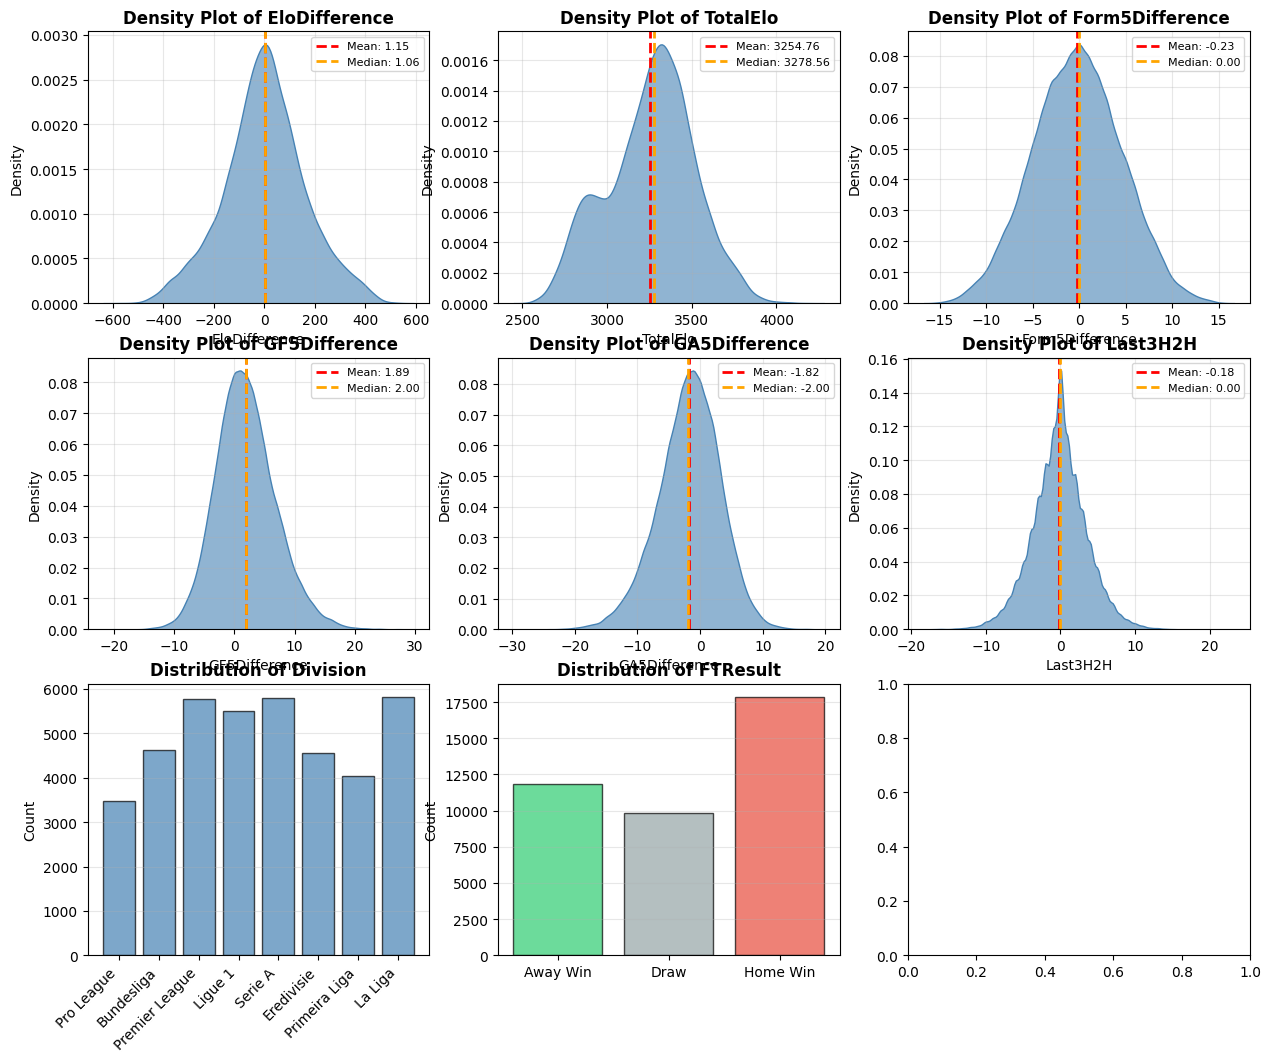

In [37]:
# Feature Visualization
# Define the type of plot for each column based on the data type
plot_types = {}

# Select numeric features for visualization (exclude identifiers and target)
columns_to_plot = [
    'EloDifference', 'TotalElo', 'Form5Difference', 
    'GF5Difference', 'GA5Difference', 'Last3H2H',
]

# Determine plot type for each feature
for col in columns_to_plot:
    unique_values = df_clean[col].nunique()
    if unique_values < 10:  # Discrete columns
        plot_types[col] = 'bar'
    else:  # Continuous columns
        plot_types[col] = 'kde'

# Add categorical columns
categorical_cols = ['Division', 'FTResult']
for col in categorical_cols:
    if col in df_clean.columns:
        plot_types[col] = 'bar'
        columns_to_plot.append(col)

# Create subplots
n_cols = 3
n_rows = (len(columns_to_plot) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
axes = axes.flatten()

# Plot each column
for i, col in enumerate(columns_to_plot):
    ax = axes[i]
    
    if plot_types[col] == 'bar':
        # For categorical and discrete data, use a count plot
        value_counts = df_clean[col].value_counts().sort_index()
        
        if col == 'FTResult':
            # Custom labels for match results
            labels = {'H': 'Home Win', 'D': 'Draw', 'A': 'Away Win'}
            colors = ['#2ecc71', '#95a5a6', '#e74c3c']
            value_counts.index = [labels.get(x, x) for x in value_counts.index]
            ax.bar(range(len(value_counts)), value_counts.values, color=colors, edgecolor='black', alpha=0.7)
            ax.set_xticks(range(len(value_counts)))
            ax.set_xticklabels(value_counts.index, rotation=0)
        elif col == 'Division':
            # Custom labels for leagues
            league_names = {
                'E0': 'Premier League', 'SP1': 'La Liga', 'I1': 'Serie A',
                'D1': 'Bundesliga', 'F1': 'Ligue 1', 'N1': 'Eredivisie',
                'B1': 'Pro League', 'P1': 'Primeira Liga'
            }
            value_counts.index = [league_names.get(x, x) for x in value_counts.index]
            ax.bar(range(len(value_counts)), value_counts.values, color='steelblue', edgecolor='black', alpha=0.7)
            ax.set_xticks(range(len(value_counts)))
            ax.set_xticklabels(value_counts.index, rotation=45, ha='right')
        else:
            ax.bar(range(len(value_counts)), value_counts.values, color='steelblue', edgecolor='black', alpha=0.7)
            ax.set_xticks(range(len(value_counts)))
            ax.set_xticklabels(value_counts.index, rotation=45, ha='right')
        
        ax.set_title(f'Distribution of {col}', fontweight='bold', fontsize=12)
        ax.set_ylabel('Count')
        ax.grid(axis='y', alpha=0.3)
        
    else:
        # For continuous data, use a density plot
        sns.kdeplot(df_clean[col].dropna(), ax=ax, fill=True, color='steelblue', alpha=0.6)
        ax.axvline(df_clean[col].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df_clean[col].mean():.2f}')
        ax.axvline(df_clean[col].median(), color='orange', linestyle='--', linewidth=2, label=f'Median: {df_clean[col].median():.2f}')
        ax.set_title(f'Density Plot of {col}', fontweight='bold', fontsize=12)
        ax.set_xlabel(col)
        ax.set_ylabel('Density')
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

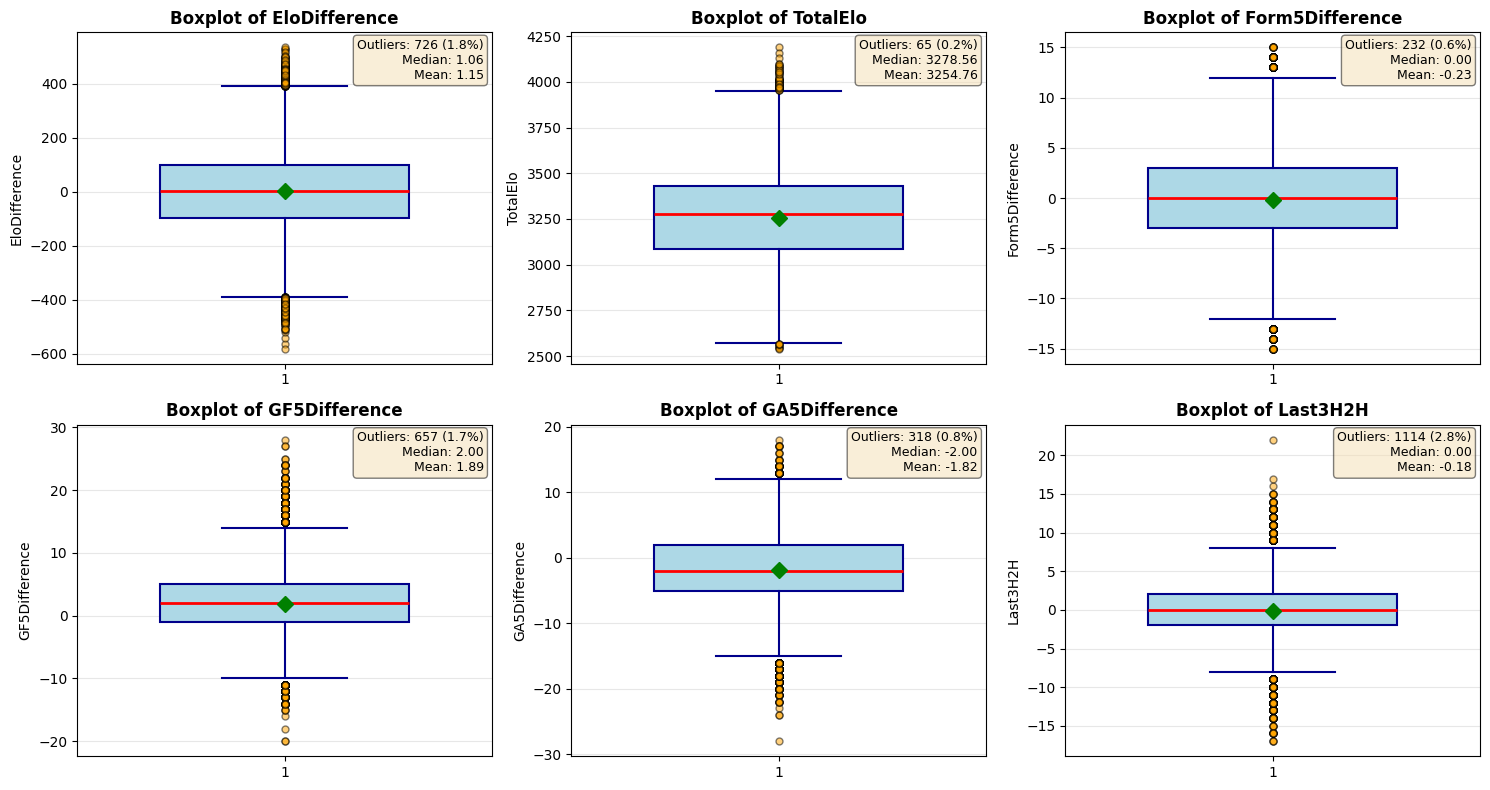

In [15]:
# Boxplot Analysis for Outlier Detection
# Select numeric columns only
numeric_columns = df_clean.select_dtypes(include=['int64', 'float64']).columns

# Filter to relevant features (exclude identifiers)
features_for_boxplot = [col for col in numeric_columns if col in [
    'EloDifference', 'TotalElo', 'Form5Difference', 
    'GF5Difference', 'GA5Difference', 'Last3H2H',
]]

n_cols = 3
n_rows = (len(features_for_boxplot) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
axes = axes.flatten()

# Create boxplots for each numeric feature
for i, col in enumerate(features_for_boxplot):
    ax = axes[i]
    
    # Create boxplot
    bp = ax.boxplot(df_clean[col].dropna(), vert=True, patch_artist=True, 
                    widths=0.6, showmeans=True,
                    boxprops=dict(facecolor='lightblue', edgecolor='darkblue', linewidth=1.5),
                    whiskerprops=dict(color='darkblue', linewidth=1.5),
                    capprops=dict(color='darkblue', linewidth=1.5),
                    medianprops=dict(color='red', linewidth=2),
                    meanprops=dict(marker='D', markerfacecolor='green', markeredgecolor='green', markersize=8),
                    flierprops=dict(marker='o', markerfacecolor='orange', markersize=5, alpha=0.5))
    
    ax.set_title(f'Boxplot of {col}', fontweight='bold', fontsize=12)
    ax.set_ylabel(col)
    ax.grid(axis='y', alpha=0.3)
    
    # Add statistics text
    q1 = df_clean[col].quantile(0.25)
    q3 = df_clean[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = ((df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)).sum()
    outlier_pct = (outliers / len(df_clean[col].dropna())) * 100
    
    stats_text = f'Outliers: {outliers} ({outlier_pct:.1f}%)\nMedian: {df_clean[col].median():.2f}\nMean: {df_clean[col].mean():.2f}'
    ax.text(0.98, 0.98, stats_text, transform=ax.transAxes, 
            fontsize=9, verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.tight_layout()
plt.show()

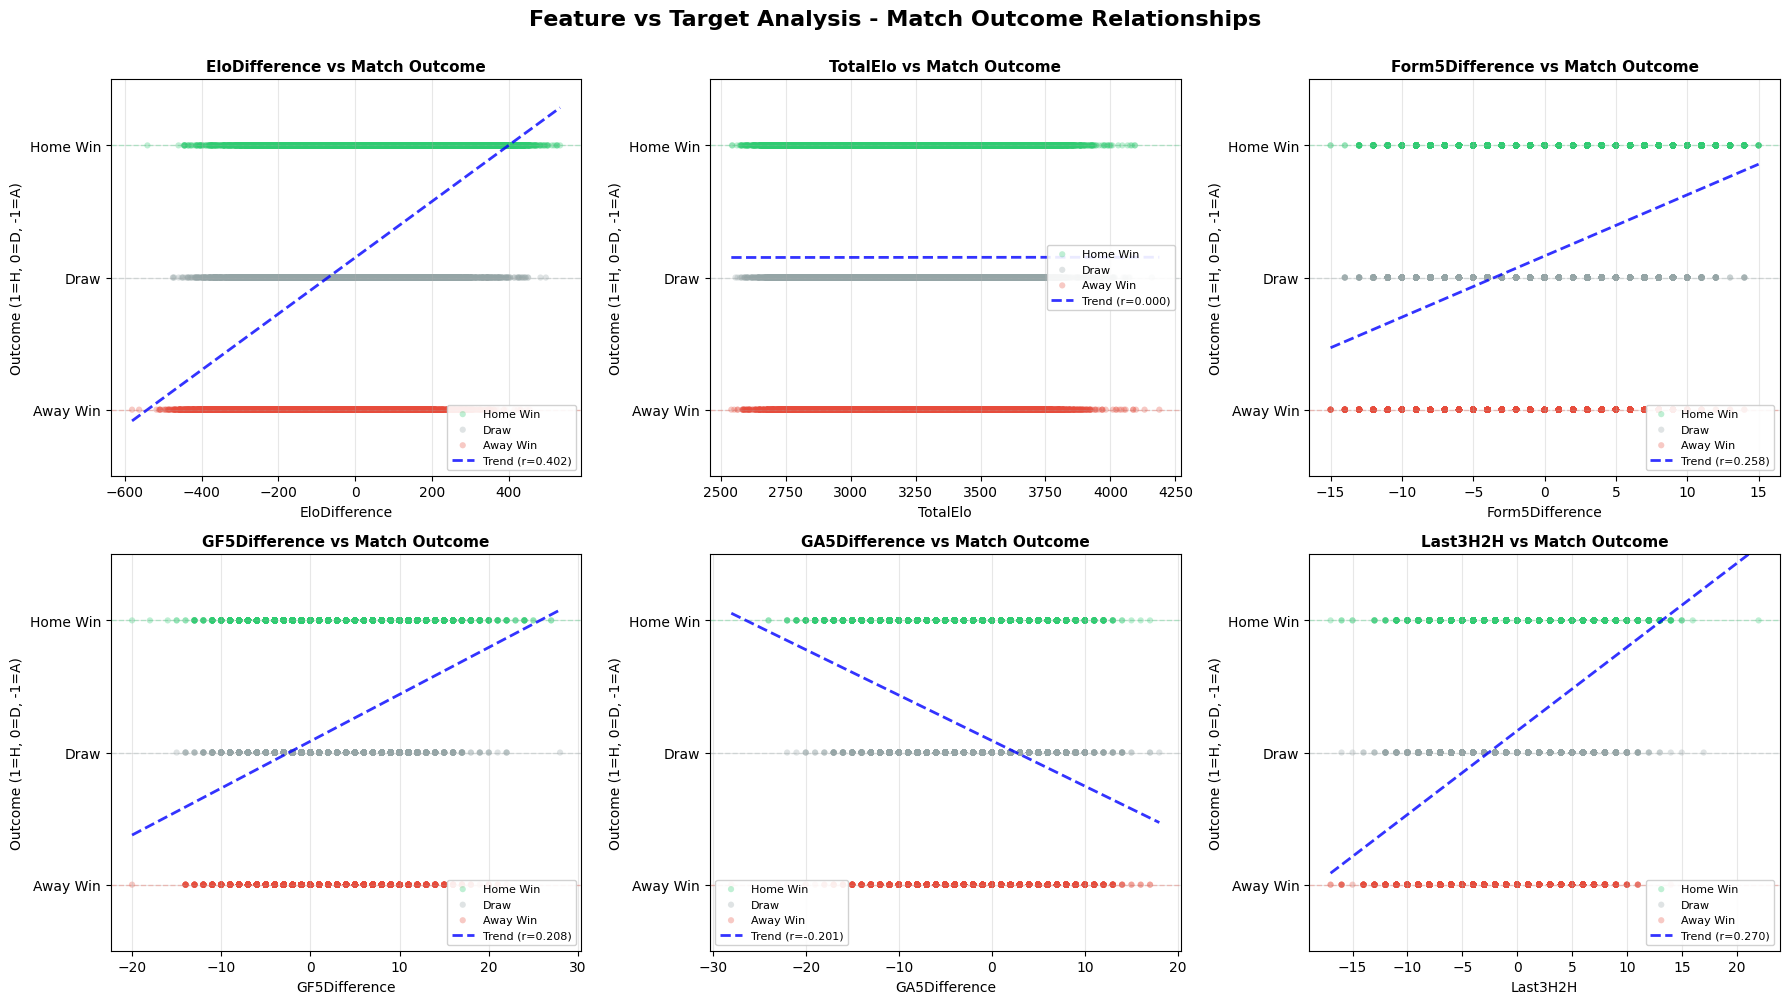


Correlation with Match Outcome (1=Home Win, 0=Draw, -1=Away Win):
EloDifference       :  0.4019
TotalElo            :  0.0004
Form5Difference     :  0.2585
GF5Difference       :  0.2077
GA5Difference       : -0.2007
Last3H2H            :  0.2700


In [18]:
# Feature vs Target Analysis
# Encode target for correlation analysis
target_encoded = df_clean['FTResult'].map({'H': 1, 'D': 0, 'A': -1})

# Select numeric features (exclude identifiers and odds)
features = [
    'EloDifference', 'TotalElo', 'Form5Difference', 
    'GF5Difference', 'GA5Difference', 'Last3H2H'
]

n_cols = 3
n_rows = (len(features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 5))
axes = axes.flatten()

# Plot each feature against the target variable
for i, feature in enumerate(features):
    ax = axes[i]
    
    # Create scatter plot with color coding for match result
    for result, color, label in [('H', '#2ecc71', 'Home Win'), 
                                   ('D', '#95a5a6', 'Draw'), 
                                   ('A', '#e74c3c', 'Away Win')]:
        mask = df_clean['FTResult'] == result
        ax.scatter(df_clean.loc[mask, feature], 
                  target_encoded[mask],
                  alpha=0.3, s=20, c=color, label=label, edgecolors='none')
    
    # Add horizontal lines for each outcome
    ax.axhline(y=1, color='#2ecc71', linestyle='--', linewidth=1, alpha=0.3)
    ax.axhline(y=0, color='#95a5a6', linestyle='--', linewidth=1, alpha=0.3)
    ax.axhline(y=-1, color='#e74c3c', linestyle='--', linewidth=1, alpha=0.3)
    
    # Calculate correlation
    correlation = df_clean[feature].corr(target_encoded)
    
    # Add trend line
    z = np.polyfit(df_clean[feature].dropna(), target_encoded.dropna(), 1)
    p = np.poly1d(z)
    x_trend = np.linspace(df_clean[feature].min(), df_clean[feature].max(), 100)
    ax.plot(x_trend, p(x_trend), "b--", linewidth=2, alpha=0.8, label=f'Trend (r={correlation:.3f})')
    
    ax.set_title(f'{feature} vs Match Outcome', fontweight='bold', fontsize=11)
    ax.set_xlabel(feature, fontsize=10)
    ax.set_ylabel('Outcome (1=H, 0=D, -1=A)', fontsize=10)
    ax.set_ylim(-1.5, 1.5)
    ax.set_yticks([-1, 0, 1])
    ax.set_yticklabels(['Away Win', 'Draw', 'Home Win'])
    ax.legend(fontsize=8, loc='best', framealpha=0.9)
    ax.grid(alpha=0.3)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Feature vs Target Analysis - Match Outcome Relationships', 
             fontsize=16, fontweight='bold', y=1.00)
fig.tight_layout()
plt.show()

# Print correlation analysis
print("\nCorrelation with Match Outcome (1=Home Win, 0=Draw, -1=Away Win):")

correlations = {}
for feature in features:
    corr = df_clean[feature].corr(target_encoded)
    correlations[feature] = corr

    
    print(f"{feature:20s}: {corr:>7.4f}")

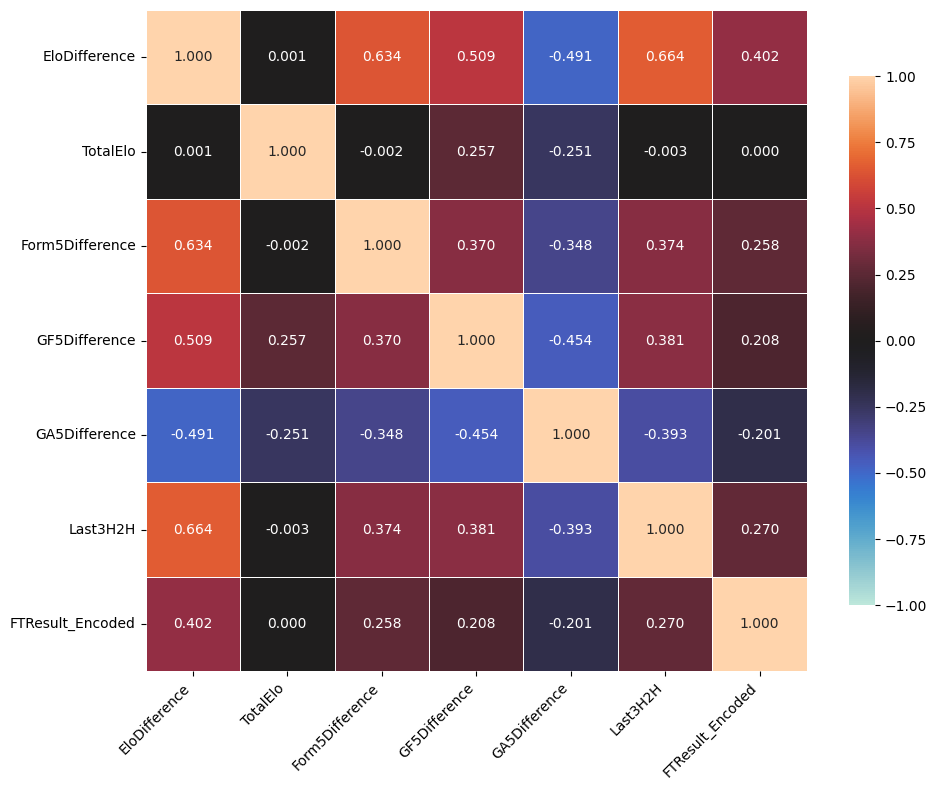

In [17]:
# Correlation Heatmap
# Prepare dataframe with numeric features and encoded target
df_corr = df_clean[features].copy()
df_corr['FTResult_Encoded'] = target_encoded

# Calculate correlation matrix
corr = df_corr.corr(numeric_only=True)

# Create heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, vmin=-1, vmax=1, annot=True, fmt='.3f', cmap='icefire', square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Model Training

Now that we've explored and understood our data, it's time to build a machine learning model to predict match outcomes.

**Our approach:**
1. Convert match results to numbers the model can understand
2. Split data into training and testing sets (chronologically)
3. Train an XGBoost classifier
4. Evaluate performance and compare with betting odds

**Why XGBoost?**
- Handles non-linear relationships well
- Works great with tabular data
- Fast and accurate
- Provides feature importance

### Encode Target Variable

We convert match results to numeric labels:
- **H (Home win)** → 0
- **D (Draw)** → 1  
- **A (Away win)** → 2

In [20]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# TARGET ENCODING (H, D, A → 0,1,2)

df = df_clean.copy()

label_map = {"H": 0, "D": 1, "A": 2}
df["Target"] = df["FTResult"].map(label_map)

### Train-Test Split (Time-Based)

**Why time-based split?**
We can't use random splitting because we want to simulate real-world prediction:
- **Training set**: Past matches (first 80% chronologically)
- **Test set**: Future matches (last 20% chronologically)

This ensures the model doesn't "see the future" during training. We're testing if it can predict matches it has never seen before, just like in real forecasting.

**Features used for prediction:**
1. `EloDifference` - Team strength gap
2. `TotalElo` - Combined team quality
3. `Form5Difference` - Recent form (last 5 matches)
4. `GF5Difference` - Goals scored gap
5. `GA5Difference` - Goals conceded gap
6. `Last3H2H` - Head-to-head history

In [21]:
# TIME-BASED TRAIN TEST SPLIT (no leakage)

FEATURES = [
    "EloDifference",
    "TotalElo",
    "Form5Difference",
    "GF5Difference",
    "GA5Difference",
    "Last3H2H"
]

X = df[FEATURES]
y = df["Target"]


df_sorted = df.sort_values("MatchDate")
split_index = int(len(df_sorted) * 0.8)

train_df = df_sorted.iloc[:split_index]
test_df  = df_sorted.iloc[split_index:]

X_train = train_df[FEATURES]
y_train = train_df["Target"]

X_test  = test_df[FEATURES]
y_test  = test_df["Target"]

print("Train size:", len(train_df))
print("Test size:", len(test_df))

Train size: 31668
Test size: 7918


### Train XGBoost Model

**XGBoost Hyperparameters explained:**
- `n_estimators=400` - Number of decision trees to build (more trees = better learning, but slower)
- `max_depth=6` - How deep each tree can grow (prevents overfitting)
- `learning_rate=0.05` - How much each tree contributes (smaller = more careful learning)
- `subsample=0.8` - Use 80% of data for each tree (adds randomness, reduces overfitting)
- `colsample_bytree=0.8` - Use 80% of features for each tree (prevents over-reliance on one feature)
- `objective="multi:softprob"` - Predict probabilities for 3 classes (Home/Draw/Away)
- `eval_metric="mlogloss"` - Measure how well-calibrated probabilities are

**Training process:**
The model learns patterns from ~42,000 historical matches to understand which feature combinations lead to home wins, draws, or away wins.

In [ ]:
# TRAIN XGBOOST 

model = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    eval_metric="mlogloss"
)

model.fit(X_train, y_train)

### Evaluate Model Performance

Now we test the model on matches it has never seen before (the test set).

**Key metrics:**
- **Log Loss**: Measures how well-calibrated the probabilities are. Lower is better. Good models have log loss around 1.0-1.1.
- **Accuracy**: Percentage of correct predictions. Random guessing would be ~33% (1 out of 3 outcomes).

In [ ]:
# EVALUATE
y_proba = model.predict_proba(X_test)
y_pred = np.argmax(y_proba, axis=1)
from sklearn.metrics import log_loss

print(f"Log Loss:  {log_loss(y_test, y_proba):.4f}")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")



 OVERALL METRICS
----------------------------------------------------------------------------------------------------
Log Loss:  0.9826
Accuracy:  0.5296


### Confusion Matrix

In [27]:
print(confusion_matrix(y_test, y_pred))

[[2878   73  542]
 [1351   44  580]
 [1114   65 1271]]


### Analyze Prediction Confidence

The model outputs probabilities for each outcome (Home/Draw/Away). The **maximum probability** indicates the model's confidence.

**Understanding confidence:**
- **High confidence (≥70%)**: Model is very sure about the prediction
- **Medium confidence (50-70%)**: Model has a preference but isn't certain
- **Low confidence (33-50%)**: Model sees it as a close call

**Key insight:**
When the model is highly confident (≥70%), it should be correct more often. If not, the model isn't well-calibrated.

**What we're analyzing:**
1. Overall confidence distribution
2. Accuracy at different confidence levels
3. How many predictions are high-confidence

In [ ]:
# PROBABILITY ANALYSIS

# Get max probability for each prediction
max_proba = np.max(y_proba, axis=1)

print(f"\nConfidence Statistics:")
print(f"  Mean confidence:     {max_proba.mean():.4f}")
print(f"  Median confidence:   {np.median(max_proba):.4f}")
print(f"  Std Dev:             {max_proba.std():.4f}")
print(f"  Min confidence:      {max_proba.min():.4f}")
print(f"  Max confidence:      {max_proba.max():.4f}")

# Confidence bins
confidence_bins = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
print(f"\nPredictions by Confidence Level:")
for i in range(len(confidence_bins)-1):
    lower, upper = confidence_bins[i], confidence_bins[i+1]
    mask = (max_proba >= lower) & (max_proba < upper)
    count = mask.sum()
    pct = count / len(max_proba) * 100
    bin_acc = accuracy_score(y_test[mask], y_pred[mask]) if count > 0 else 0
    print(f"  {lower:.1f}-{upper:.1f}: {count:>6,} predictions ({pct:>5.1f}%) | Accuracy: {bin_acc:.4f}")

# Last bin (1.0)
mask = max_proba >= confidence_bins[-1]
count = mask.sum()
pct = count / len(max_proba) * 100
bin_acc = accuracy_score(y_test[mask], y_pred[mask]) if count > 0 else 0
print(f"  {confidence_bins[-1]:.1f}:      {count:>6,} predictions ({pct:>5.1f}%) | Accuracy: {bin_acc:.4f}")


high_conf_mask = max_proba >= 0.7
high_conf_acc = accuracy_score(y_test[high_conf_mask], y_pred[high_conf_mask])
high_conf_pct = high_conf_mask.sum() / len(max_proba) * 100

print(f"""
High Confidence (≥70%) Predictions:
   • Count:    {high_conf_mask.sum():,} ({high_conf_pct:.1f}% of test set)
   • Accuracy: {high_conf_acc:.4f}
""")


Confidence Statistics:
  Mean confidence:     0.5450
  Median confidence:   0.5089
  Std Dev:             0.1440
  Min confidence:      0.3356
  Max confidence:      0.9812

Predictions by Confidence Level:
  0.3-0.4:  1,146 predictions ( 14.5%) | Accuracy: 0.3700
  0.4-0.5:  2,612 predictions ( 33.0%) | Accuracy: 0.4445
  0.5-0.6:  1,763 predictions ( 22.3%) | Accuracy: 0.5264
  0.6-0.7:  1,040 predictions ( 13.1%) | Accuracy: 0.6394
  0.7-0.8:    800 predictions ( 10.1%) | Accuracy: 0.7137
  0.8-0.9:    426 predictions (  5.4%) | Accuracy: 0.7793
  0.9-1.0:    131 predictions (  1.7%) | Accuracy: 0.8550
  1.0:           0 predictions (  0.0%) | Accuracy: 0.0000


HIGH CONFIDENCE PREDICTONS

High Confidence (≥70%) Predictions:
   • Count:    1,357 (17.1% of test set)
   • Accuracy: 0.7480



### Compare with Bet365 Betting Odds

**Why compare with bookmakers?**
Betting companies like Bet365 are considered the "gold standard" for match prediction because:
- They have expert analysts and decades of experience
- They incorporate real-time information (injuries, team news, weather)
- Their odds reflect the collective wisdom of millions of bets
- They're extremely accurate (or they'd lose money!)

**How we compare:**
We convert Bet365 odds to implied probabilities and compare against our model using the same metrics (accuracy and log loss).

#### Converting Betting Odds to Probabilities

**How betting odds work:**
- Odds of 2.00 mean "bet $1, win $2 if correct" → 50% probability
- Odds of 3.00 → 33.3% probability
- Odds of 1.50 → 66.7% probability

**Formula:** Implied Probability = 1 / Odds

**Normalization:**
Bookmakers add a margin (called "overround"), so probabilities sum to more than 100%. We normalize them to sum to exactly 100% for fair comparison.

In [29]:
# Calculate Bet365 implied probabilities from test set
test_df_reset = test_df.reset_index(drop=True)
X_test_reset = X_test.reset_index(drop=True)

p_home = 1 / test_df_reset['OddHome'].values
p_draw = 1 / test_df_reset['OddDraw'].values
p_away = 1 / test_df_reset['OddAway'].values

norm = p_home + p_draw + p_away
p_home_norm = p_home / norm
p_draw_norm = p_draw / norm
p_away_norm = p_away / norm

bet365_proba = np.column_stack([p_home_norm, p_draw_norm, p_away_norm])
bet365_pred = np.argmax(bet365_proba, axis=1)

#### Performance Comparison Metrics

We compare our model with Bet365 on two key metrics:

**1. Accuracy** (who picks the right winner more often?)
- Easier to understand: % of correct predictions
- Shows who's better at picking outcomes

**2. Log Loss** (who has better-calibrated probabilities?)
- More sophisticated: measures probability quality
- Lower is better
- A difference of 0.01-0.02 is considered significant

In [ ]:
print("ACCURACY COMPARISON")

model_acc = accuracy_score(y_test.values, y_pred)
bet365_acc = accuracy_score(y_test.values, bet365_pred)

print(f"Our Model Accuracy:      {model_acc:.4f} ({model_acc*100:.2f}%)")
print(f"Bet365 Odds Accuracy:     {bet365_acc:.4f} ({bet365_acc*100:.2f}%)")
print(f"Difference:               {(model_acc - bet365_acc):.4f} ({(model_acc - bet365_acc)*100:+.2f}%)")

print("\nLOG LOSS COMPARISON")

model_logloss = log_loss(y_test.values, y_proba)
bet365_logloss = log_loss(y_test.values, bet365_proba)

print(f"Our Model Log Loss:      {model_logloss:.4f}")
print(f"Bet365 Odds Log Loss:     {bet365_logloss:.4f}")
print(f"Difference:               {(model_logloss - bet365_logloss):.4f} ({(model_logloss - bet365_logloss)*100:+.2f}%)")

ACCURACY COMPARISON
Our Model Accuracy:      0.5296 (52.96%)
Bet365 Odds Accuracy:     0.5494 (54.94%)
Difference:               -0.0198 (-1.98%)

LOG LOSS COMPARISON
Our Model Log Loss:      0.9826
Bet365 Odds Log Loss:     0.9573
Difference:               0.0253 (+2.53%)


: 

#### Probability Differences Analysis

**Why this matters:**
Even if both predict the same winner, the *confidence levels* might differ. Understanding these differences helps us identify:
- Where our model sees value (disagrees with the market)
- Which outcomes we're more/less confident about
- Potential mispriced bets

**What we're measuring:**
- Average difference in probabilities across all matches
- Maximum differences (where model strongly disagrees with odds)
- Differences by outcome type (Home/Draw/Away)

In [36]:
# PROBABILITY DIFFERENCES"

# Calculate absolute differences
prob_diffs = np.abs(y_proba - bet365_proba)
mean_prob_diff = prob_diffs.mean()
max_prob_diff = prob_diffs.max()

print(f"\nMean absolute probability difference: {mean_prob_diff:.4f}")
print(f"Max probability difference:           {max_prob_diff:.4f}")

# For each outcome, where does model differ most?
for class_idx, class_name in enumerate(['Home Win', 'Draw', 'Away Win']):
    diff = np.abs(y_proba[:, class_idx] - bet365_proba[:, class_idx])
    print(f"\n{class_name}:")
    print(f"  Mean diff:              {diff.mean():.4f}")
    print(f"  Max diff:               {diff.max():.4f}")


Mean absolute probability difference: 0.0530
Max probability difference:           0.4328

Home Win:
  Mean diff:              0.0615
  Max diff:               0.3781

Draw:
  Mean diff:              0.0413
  Max diff:               0.4328

Away Win:
  Mean diff:              0.0562
  Max diff:               0.3813


In [34]:
# AGREEMENT ANALYSIS

# How often do they predict the same outcome?
same_pred = (y_pred == bet365_pred).sum()
same_pct = same_pred / len(y_pred) * 100

print(f"\nPredictions agreeing:     {same_pred:,} ({same_pct:.1f}%)")
print(f"Predictions diverging:    {len(y_pred) - same_pred:,} ({100-same_pct:.1f}%)")

# When they agree, how accurate are they?
agree_mask = y_pred == bet365_pred
if agree_mask.sum() > 0:
    agree_acc = accuracy_score(y_test.values[agree_mask], y_pred[agree_mask])
    print(f"\nWhen agreeing - Accuracy: {agree_acc:.4f}")

# When they disagree, who's right?
disagree_mask = y_pred != bet365_pred
if disagree_mask.sum() > 0:
    model_acc_disagree = accuracy_score(y_test.values[disagree_mask], y_pred[disagree_mask])
    bet365_acc_disagree = accuracy_score(y_test.values[disagree_mask], bet365_pred[disagree_mask])
    print(f"\nWhen disagreeing:")
    print(f"  Model accuracy:         {model_acc_disagree:.4f}")
    print(f"  Bet365 accuracy:        {bet365_acc_disagree:.4f}")


Predictions agreeing:     6,915 (87.3%)
Predictions diverging:    1,003 (12.7%)

When agreeing - Accuracy: 0.5659

When disagreeing:
  Model accuracy:         0.2792
  Bet365 accuracy:        0.4357


#### Agreement Analysis: When Do We Agree/Disagree?

**Agreement rate:**
How often do our model and Bet365 predict the same outcome?

**When they agree:**
- Both see the same favorite → High confidence in that prediction
- Usually means the match outcome is relatively clear

**When they disagree:**
- This is where it gets interesting!
- If our model is right more often → We've found an edge
- If Bet365 is right more often → Market knows something we don't
- These matches are potential value betting opportunities

**Key question:** Who's more accurate when predictions diverge?

## Future Improvements

The current model achieves ~53% accuracy, competitive with professional odds. Here are some ideas to potentially improve it further:

### 1. **Elo Momentum** 
Instead of just current Elo, track how fast teams are improving/declining:
- `EloMomentum = (Recent Elo Change) - (Opponent's Elo Change)`
- Shows which team has momentum

### 2. **Team-Specific Home Advantage**
Some teams are much stronger at home than others:
- `HomeAdvantage = (Team's Home Win Rate) - (Team's Away Win Rate)`
- Example: Team A might be +15% at home, Team B only +5%

### 3. **Rest Days**
Fatigue matters for performance:
- Track days between matches
- Teams with less rest might underperform

### 4. **Weighted Form**
Current form should count more against strong opponents:
- Instead of just counting wins/losses, weight them by opponent strength
- A win against the best team = more points than a win against a weak team

### 5. **Try Other Models**
- Random Forest, LightGBM, or ensemble methods might perform better
- Neural networks for non-linear patterns

### Save the model

In [ ]:
import pickle

# Save
artifacts = {
    "model": model,
    "features": FEATURES,
    "label_map": label_map,
}
with open("model.pkl", "wb") as f:
    pickle.dump(artifacts, f)

# Load
with open("model.pkl", "rb") as f:
    loaded = pickle.load(f)

model = loaded["model"]
FEATURES = loaded["features"]
label_map = loaded["label_map"]

## Explainability AI (XAI)

Now that we have a trained model that predicts match outcomes, we need to understand **why** it makes certain predictions.

**The Problem:**
Machine learning models are often "black boxes" - we can see predictions, but not the reasoning behind them. This is a problem because:
- We can't trust predictions we don't understand
- We can't improve the model without knowing what it's learning
- Stakeholders (coaches, analysts) need explanations, not just numbers

**The Solution: SHAP (SHapley Additive exPlanations)**
SHAP is a powerful tool that tells us:
- Which features are most important overall
- How each feature influences specific predictions
- Whether high/low feature values increase or decrease probabilities

Think of SHAP as showing the "reasoning" behind each prediction, just like a human expert would explain their forecast.

### Initialize SHAP Explainer

**What we're doing:**
Creating a SHAP explainer specifically designed for tree-based models (like XGBoost).

**How it works:**
- The explainer analyzes the internal structure of our trained model
- For each prediction, it calculates how much each feature contributed
- It uses game theory (Shapley values) to fairly distribute "credit" among features

**What `shap_values` contains:**
For each test match, we get 6 numbers (one per feature) showing:
- Positive values = feature pushed prediction toward that outcome
- Negative values = feature pushed prediction away from that outcome
- Larger magnitude = stronger influence

In [ ]:
# Train SHAP explainer and compute shap_values for X_test
import shap
shap.initjs()
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)
X_test.head(), shap_values[0].values[:8]

(       EloDifference  TotalElo  Form5Difference  GF5Difference  GA5Difference  \
 2693           45.39   3676.81              4.0            6.0          -10.0   
 2396           41.87   3424.33              1.0           -1.0           -2.0   
 4463          115.79   3412.11             -3.0            2.0           -1.0   
 37213        -356.82   3416.98             -7.0            1.0           -3.0   
 37787        -161.39   3357.63             -4.0           -7.0            0.0   
 
        Last3H2H  
 2693        0.0  
 2396        1.0  
 4463        0.0  
 37213      -8.0  
 37787      -4.0  ,
 array([[ 0.2482076 , -0.04639852, -0.2114629 ],
        [-0.05091945,  0.06999585, -0.08992448],
        [ 0.06106501, -0.00440322,  0.04219662],
        [-0.0053947 ,  0.03443903, -0.04947913],
        [ 0.04502483, -0.0273413 , -0.08592653],
        [-0.03049334,  0.01744589,  0.0100097 ]], dtype=float32))

### Global Explainability - Feature Importance

**What this plot shows:**
A summary of which features matter most across ALL predictions in the test set.

**How to read it:**
- **Y-axis**: Features ranked by importance (top = most important)
- **X-axis**: SHAP value (impact on prediction)
- **Color**: Feature value (red = high, blue = low)
- **Spread**: How much the feature's impact varies

**What to look for:**
1. **Top features**: Which variables drive most predictions?
2. **Color patterns**: 
   - Red dots on the right = high feature values increase this outcome
   - Blue dots on the left = low feature values decrease this outcome
3. **Spread**: Wide spread = feature has varied impact depending on context

**Example interpretation:**
If `EloDifference` is at the top with red dots on the right:
- "When home team has higher Elo (red), it strongly increases home win probability"

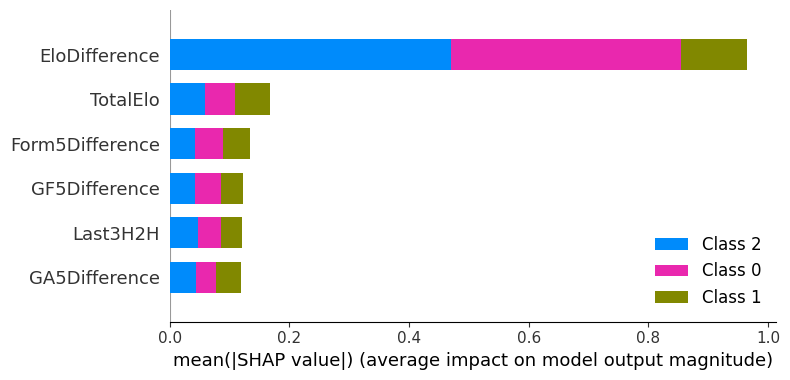

In [ ]:
#Global Explainability
shap.summary_plot(shap_values, X_test)

### Class-Specific Explainability

**Why separate by outcome?**
Our model predicts 3 different outcomes (Home/Draw/Away), and features might influence each differently:
- `EloDifference` might strongly affect Home Win, but less so for Draws
- `Form5Difference` might be crucial for predicting Draws
- `Last3H2H` might matter more for specific rivalries

**What we're doing:**
For each outcome class, we'll see:
1. **Summary plot**: How features affect that specific outcome across all matches
2. **Bar chart**: Average importance for that outcome
3. **Dependence plots**: Detailed view of how key features (Elo, Form, H2H) work

**The three classes:**
- **Class 0 (Home Win)**: What makes the model predict home team will win?
- **Class 1 (Draw)**: What signals a draw?
- **Class 2 (Away Win)**: What favors the away team?

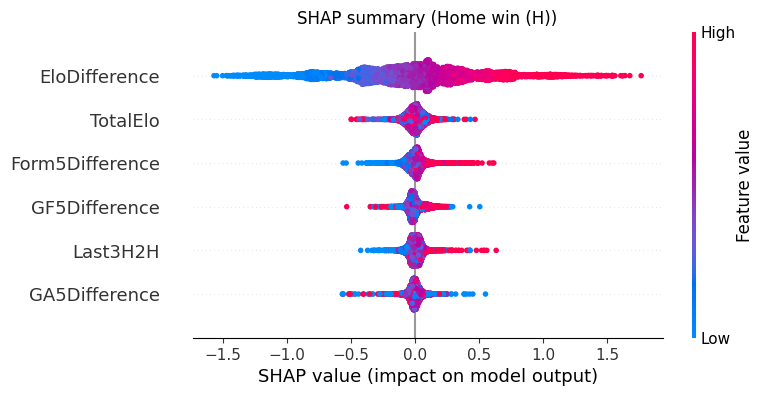

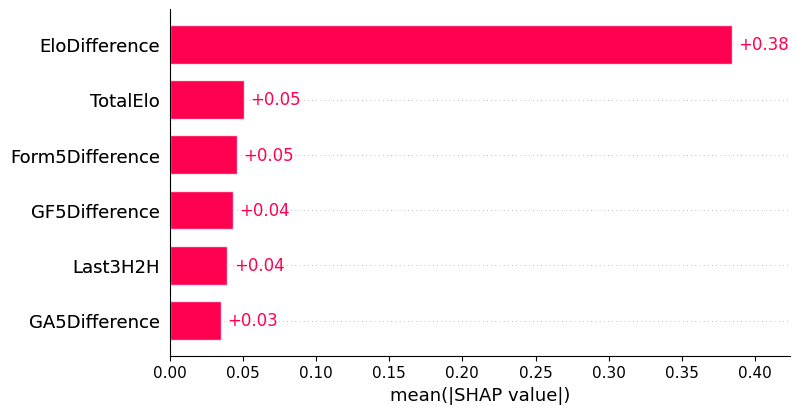

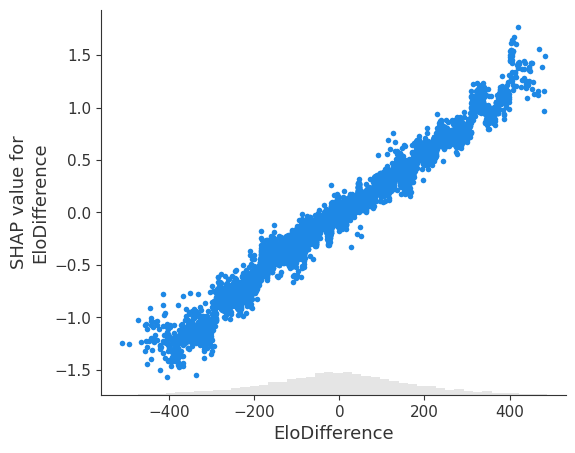

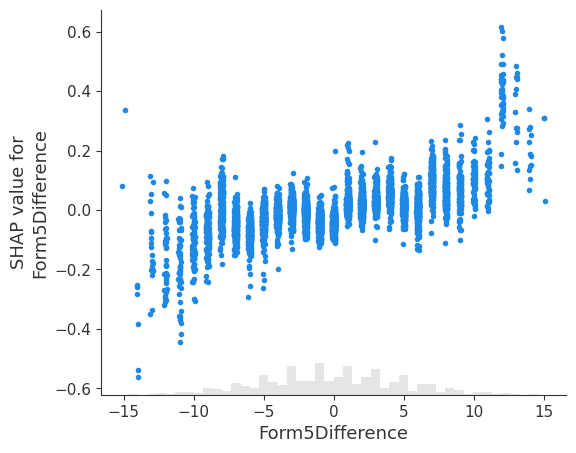

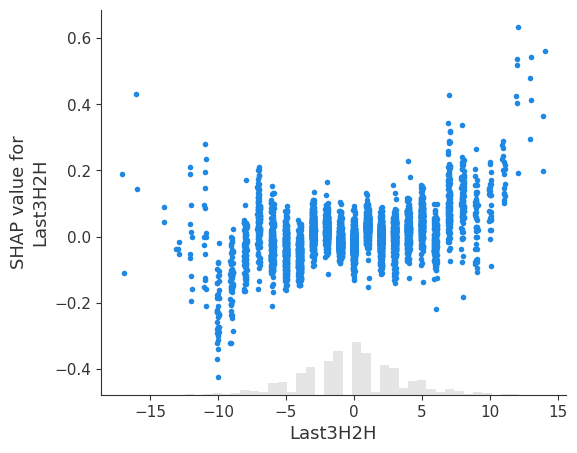

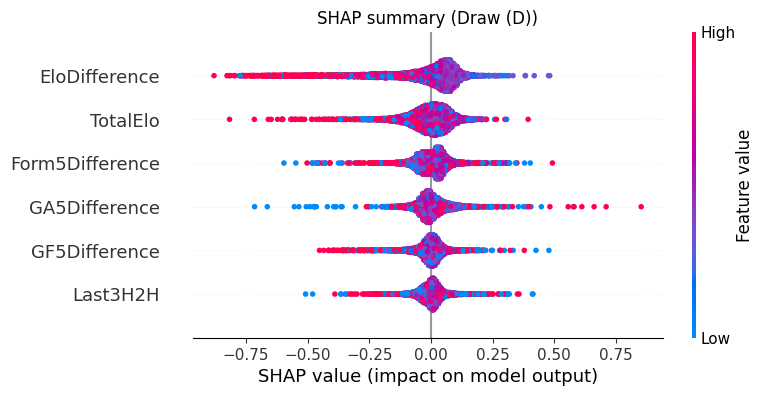

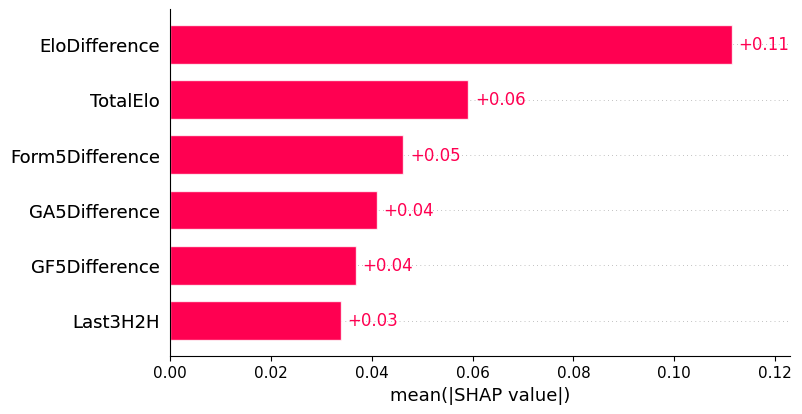

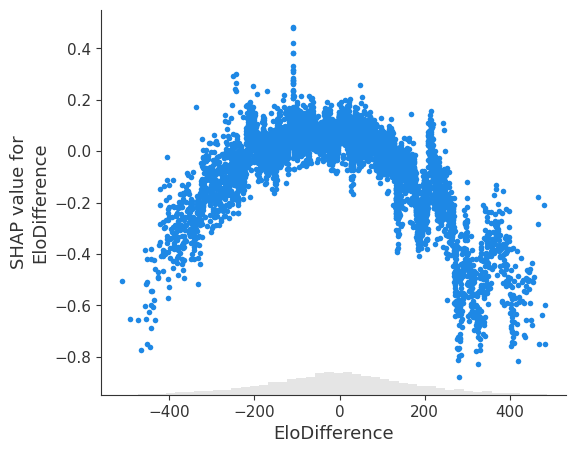

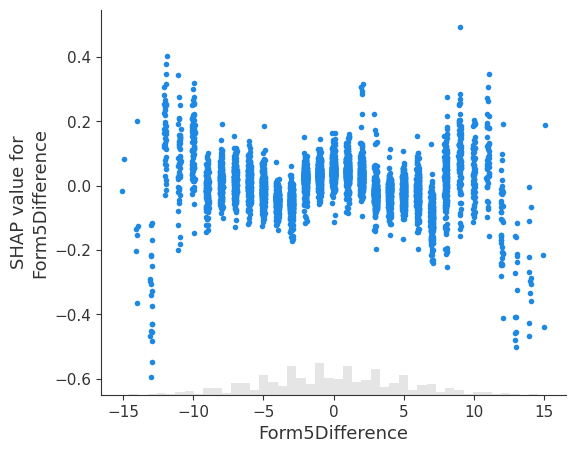

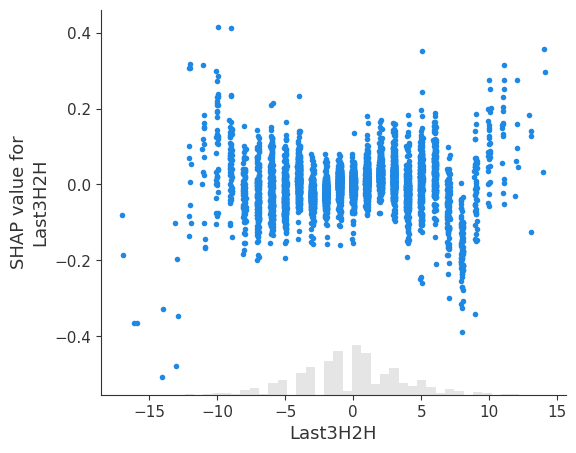

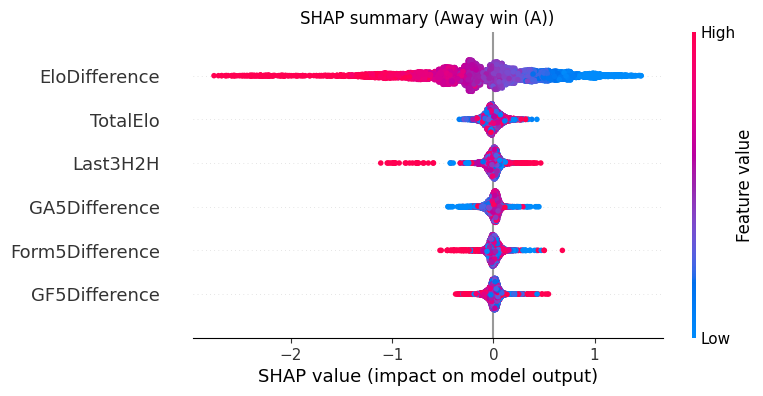

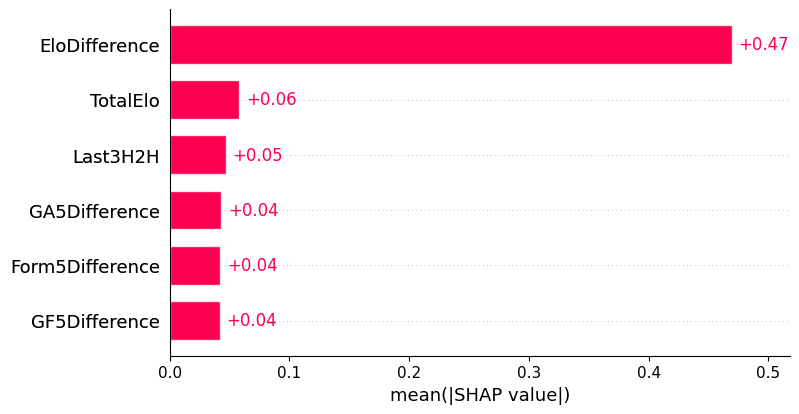

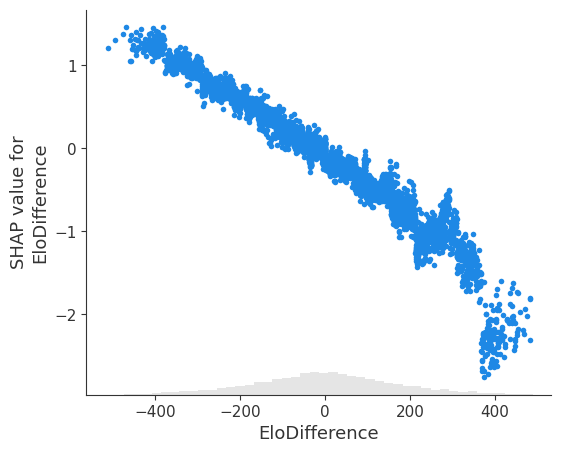

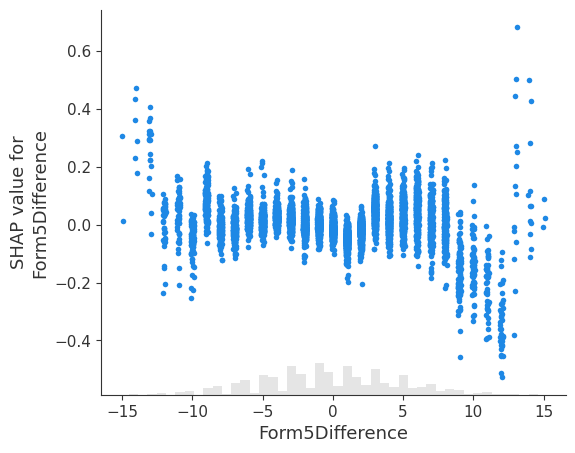

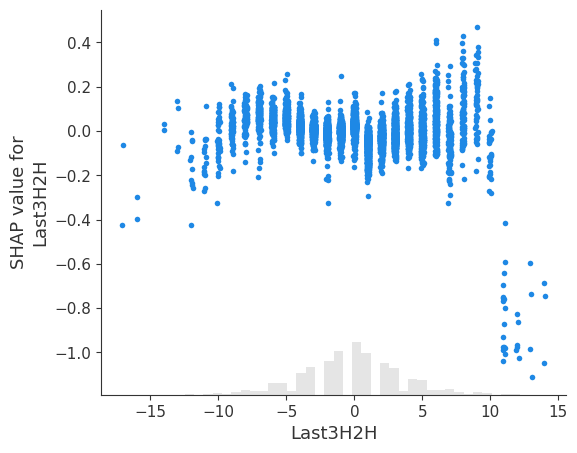

In [ ]:
# SHAP explainability (class-specific)
class_names = ['Home win (H)', 'Draw (D)', 'Away win (A)']
class_idx = [0,1,2]  # 0=H, 1=D, 2=A

for class_idx in class_idx:
    # Global: summary & bar for the selected class
    shap.summary_plot(shap_values[..., class_idx], X_test, show=False)
    plt.title(f"SHAP summary ({class_names[class_idx]})")
    plt.show()

    shap.plots.bar(shap_values[..., class_idx], max_display=10)

    # Global: dependence on a few key features
    shap.plots.scatter(shap_values[..., class_idx][:, "EloDifference"])
    shap.plots.scatter(shap_values[..., class_idx][:, "Form5Difference"])
    shap.plots.scatter(shap_values[..., class_idx][:, "Last3H2H"])

#### Understanding the Plots

**1. Summary Plot (for each class):**
- Shows all features for a specific outcome (e.g., Home Win)
- Helps identify which features are most important for that outcome specifically

**2. Bar Chart:**
- Simple ranking of features by average impact
- Quick way to see the "top 3" drivers for each outcome

**3. Dependence (Scatter) Plots:**
These show the relationship between a feature's value and its impact:

**Example: EloDifference for Home Win**
- X-axis: Actual EloDifference values (-400 to +400)
- Y-axis: SHAP value (impact on Home Win probability)
- Pattern: As EloDifference increases (home team stronger), SHAP values increase (more likely to predict Home Win)

**Example: Form5Difference for Draw**
- Might show that when form is balanced (near 0), Draw probability increases
- When one team has much better form, Draw becomes less likely

**Example: Last3H2H**
- Shows if recent head-to-head history matters
- Positive H2H (home team dominated recently) might favor Home Win